# Lab 3: First-Visit Monte Carlo Control for Blackjack-v1

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict

## First-Visit MC Control with ε-Soft Policy

In [2]:
def mc_control(env, n_episodes=500000, gamma=1.0, epsilon=0.1):
    """First-visit MC control with epsilon-soft policy (S&B Section 5.4)."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_count = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(lambda: np.zeros(env.action_space.n))

    # Track average returns for learning curve
    rewards_log = []

    for ep in range(n_episodes):
        # --- Generate episode using epsilon-soft policy ---
        episode = []
        state, _ = env.reset()
        done = False
        while not done:
            if state in Q:
                if np.random.random() < epsilon:
                    action = env.action_space.sample()
                else:
                    action = int(np.argmax(Q[state]))
            else:
                action = env.action_space.sample()
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        rewards_log.append(sum(r for _, _, r in episode))

        # --- First-visit MC update ---
        G = 0.0
        visited = set()
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                returns_sum[state][action] += G
                returns_count[state][action] += 1.0
                Q[state][action] = returns_sum[state][action] / returns_count[state][action]

    return Q, rewards_log

## Train on Blackjack-v1

In [3]:
env = gym.make("Blackjack-v1", sab=True)
Q, rewards_log = mc_control(env, n_episodes=500000, gamma=1.0, epsilon=0.1)
print(f"States visited: {len(Q)}")

States visited: 280


## Extract Value Function and Policy

In [4]:
def get_value_and_policy(Q):
    """Extract V(s) = max_a Q(s,a) and policy pi(s) = argmax_a Q(s,a)."""
    V = defaultdict(float)
    policy = defaultdict(int)
    for state, actions in Q.items():
        V[state] = np.max(actions)
        policy[state] = int(np.argmax(actions))  # 0=stick, 1=hit
    return V, policy

V, policy = get_value_and_policy(Q)

## 3D Surface Plots of Value Function

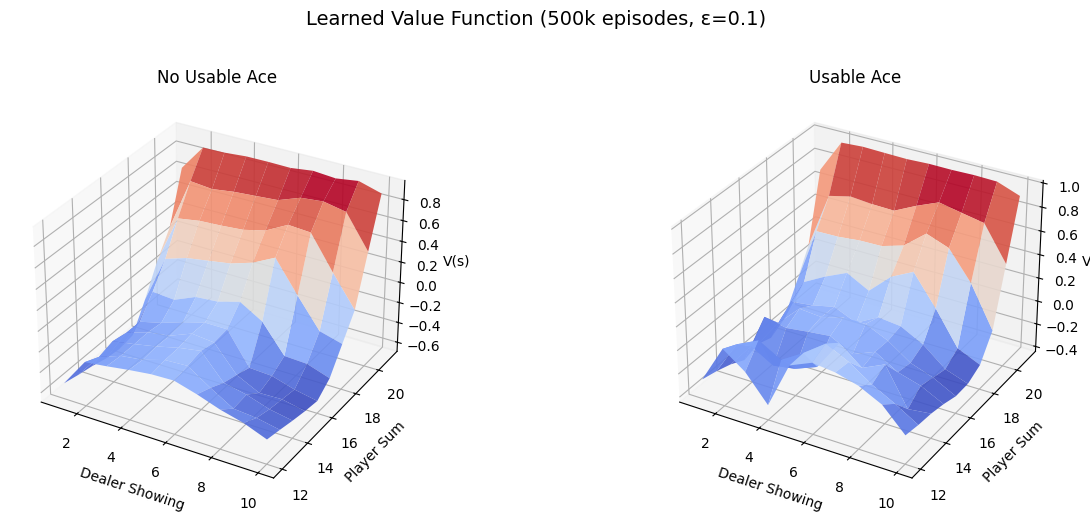

In [5]:
def plot_value_surface(V, title="Value Function"):
    """3D surface plot: player sum vs dealer showing, for usable/no-usable ace."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             subplot_kw={"projection": "3d"})
    
    for idx, usable_ace in enumerate([False, True]):
        ax = axes[idx]
        player_range = np.arange(12, 22)   # player sum 12-21
        dealer_range = np.arange(1, 11)    # dealer showing 1-10
        X, Y = np.meshgrid(dealer_range, player_range)
        Z = np.zeros_like(X, dtype=float)

        for i, p in enumerate(player_range):
            for j, d in enumerate(dealer_range):
                Z[i, j] = V.get((p, d, usable_ace), 0.0)

        ax.plot_surface(X, Y, Z, cmap="coolwarm", edgecolor="none", alpha=0.9)
        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ax.set_zlabel("V(s)")
        ace_label = "Usable Ace" if usable_ace else "No Usable Ace"
        ax.set_title(f"{ace_label}")

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("value_surface.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_value_surface(V, "Learned Value Function (500k episodes, ε=0.1)")

## Policy Heatmaps vs Basic Strategy

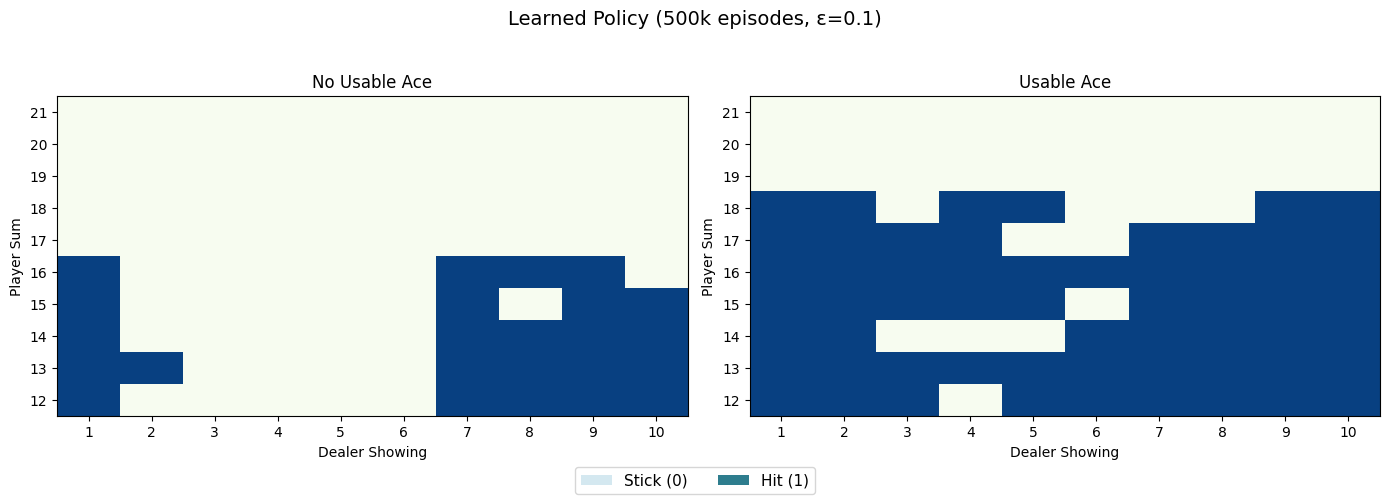

In [6]:
def plot_policy(policy, title="Learned Policy"):
    """Heatmap of policy: 0=Stick (white), 1=Hit (green)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for idx, usable_ace in enumerate([False, True]):
        ax = axes[idx]
        player_range = np.arange(12, 22)
        dealer_range = np.arange(1, 11)
        grid = np.zeros((len(player_range), len(dealer_range)))

        for i, p in enumerate(player_range):
            for j, d in enumerate(dealer_range):
                grid[i, j] = policy.get((p, d, usable_ace), 1)  # default hit

        im = ax.imshow(grid, cmap="GnBu", vmin=0, vmax=1,
                       extent=[0.5, 10.5, 11.5, 21.5], origin="lower", aspect="auto")
        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ace_label = "Usable Ace" if usable_ace else "No Usable Ace"
        ax.set_title(f"{ace_label}")
        ax.set_xticks(range(1, 11))
        ax.set_yticks(range(12, 22))

    # Legend
    from matplotlib.patches import Patch
    fig.legend([Patch(facecolor="#d4e8f0"), Patch(facecolor="#2e7d8e")],
               ["Stick (0)", "Hit (1)"], loc="lower center", ncol=2, fontsize=11)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig("policy_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_policy(policy, "Learned Policy (500k episodes, ε=0.1)")

## Learning Curve (Smoothed Average Returns)

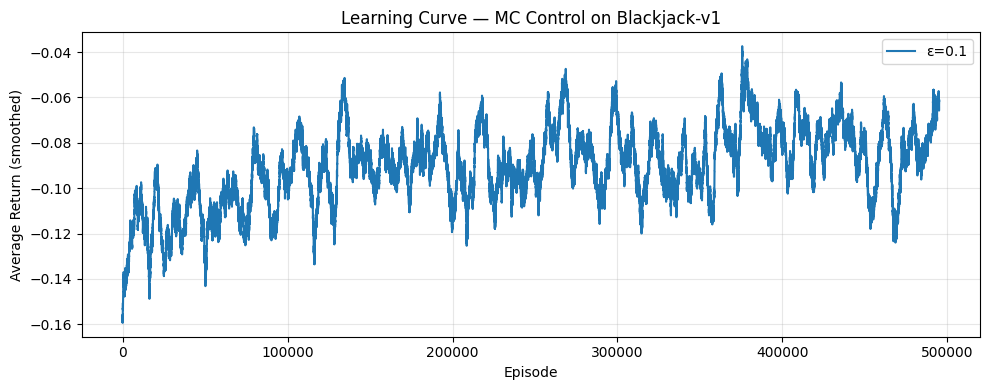

In [7]:
def plot_learning_curve(rewards_log, window=5000, label="ε=0.1"):
    """Plot smoothed average return over episodes."""
    smoothed = np.convolve(rewards_log, np.ones(window)/window, mode="valid")
    plt.plot(smoothed, label=label)

plt.figure(figsize=(10, 4))
plot_learning_curve(rewards_log, label="ε=0.1")
plt.xlabel("Episode")
plt.ylabel("Average Return (smoothed)")
plt.title("Learning Curve — MC Control on Blackjack-v1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Epsilon Comparison and Decay Schedules

In [8]:
def mc_control_decay(env, n_episodes=500000, gamma=1.0, eps_start=1.0, eps_min=0.01):
    """MC control with linear epsilon decay."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_count = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(lambda: np.zeros(env.action_space.n))
    rewards_log = []

    for ep in range(n_episodes):
        epsilon = max(eps_min, eps_start - (eps_start - eps_min) * ep / n_episodes)
        episode = []
        state, _ = env.reset()
        done = False
        while not done:
            if state in Q and np.random.random() >= epsilon:
                action = int(np.argmax(Q[state]))
            else:
                action = env.action_space.sample()
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        rewards_log.append(sum(r for _, _, r in episode))

        G = 0.0
        visited = set()
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                returns_sum[state][action] += G
                returns_count[state][action] += 1.0
                Q[state][action] = returns_sum[state][action] / returns_count[state][action]

    return Q, rewards_log

# Run experiments with different epsilon values
env = gym.make("Blackjack-v1", sab=True)

print("Training ε=0.05...")
Q_05, rewards_05 = mc_control(env, n_episodes=500000, epsilon=0.05)
print("Training ε=0.2...")
Q_20, rewards_20 = mc_control(env, n_episodes=500000, epsilon=0.2)
print("Training with linear decay (1.0 → 0.01)...")
Q_decay, rewards_decay = mc_control_decay(env, n_episodes=500000)
print("Done.")

Training ε=0.05...
Training ε=0.2...
Training with linear decay (1.0 → 0.01)...
Done.


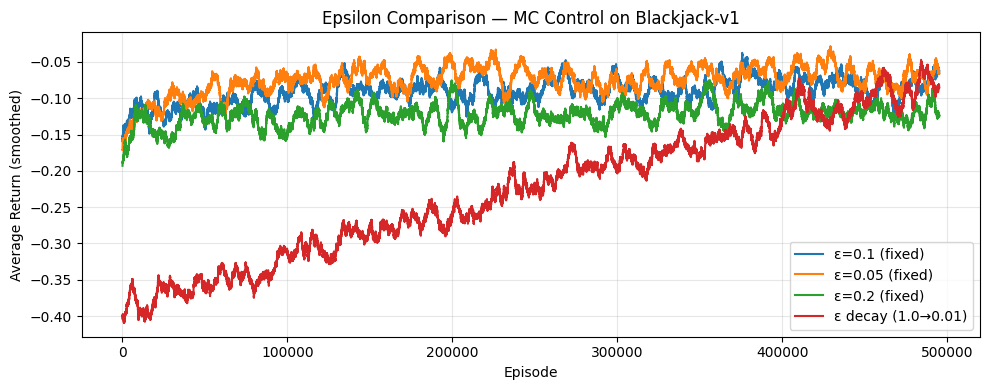

In [9]:
# Compare learning curves across epsilon settings
plt.figure(figsize=(10, 4))
plot_learning_curve(rewards_log, label="ε=0.1 (fixed)")
plot_learning_curve(rewards_05, label="ε=0.05 (fixed)")
plot_learning_curve(rewards_20, label="ε=0.2 (fixed)")
plot_learning_curve(rewards_decay, label="ε decay (1.0→0.01)")
plt.xlabel("Episode")
plt.ylabel("Average Return (smoothed)")
plt.title("Epsilon Comparison — MC Control on Blackjack-v1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("epsilon_comparison.png", dpi=150, bbox_inches="tight")
plt.show()